# Test 03 — mk2 outboard sections across their joint

Sections 02 + 03 of the mk2 wing, bonded at their printed joint, on two supports and loaded
across the joint. **It held 18 kgf with no failure.**

It was broken afterwards at a load nobody recorded. **The bore and its low-density bell came
away as a plug**, delaminating from the skin and from the lattice. The rods did not fail this time.

<p align="center">
  <img src="../../imagenes/half_wing_naca_4_series.jpg" alt="mk2 sections 02 and 03 on a 3 point bending test" width="60%">
</p>

A Note on this build: This entire wing build was not particularly great. Many mistakes were made along the way: choosing a bery bad household epoxy that never truly cured the lip-join, choosing a bad infill pattern + density surrounding the pultruded tube. The last one, was probably the failure mode seen ultimately. 

This means, although this particular 3 point bending test was not "bad" and is able to validate the reinforcements, it is only done partially. 

Calculations: The method is the transformed section from [`experiment-01`](../experiment-01/ellipse_test.ipynb),
now on the real NACA 4412 section, the real peg/sleeve joint, and one rod pair per section.

## Geometry

The wing is [`definitions/mk2/`](../../definitions/mk2/). The rod positions below come
straight from that definition, the same layout the builder prints.

<p align="center">
  <img src="../../definitions/mk2/planform.png" alt="mk2 planform" width="70%">
</p>

Relative to the full wing:

| | as built |
|---|---|
| parts | `section_02` + `section_03`, z = 400–800 mm in wing coordinates, joint at z = 600 |
| section | NACA 4412, chord 180 → 160 mm |
| rods | **one 3 mm diameter pair per section**: span 2 at x/c 0.33 (z 400–625), span 3 at x/c 0.28 (z 575–800). Two pairs only in the 50 mm lap |
| print | standing on end, **1 wall (0.42 mm)**, **5 % lattice** |
| bell | **10 % crosszag** around the primary rods. The ellipse's was 100% density |
| test | supports 400 mm apart centred on the joint, **18 kgf** uniform over ±70 mm |

In [1]:
from __future__ import annotations

import importlib.util
import math
import pathlib
import sys
from dataclasses import dataclass
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
})

G = 9.81          # m/s^2.  Lengths mm, forces N, stresses MPa throughout.

ROOT = next(p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
            if (p / "wing_assembler").is_dir())
sys.path.insert(0, str(ROOT))

from wing_assembler.naca import naca4_polygon_pts, offset_polygon
from wing_assembler.section_layout import _compute_physical_rod_sections, chord_at

spec = importlib.util.spec_from_file_location("_mk2", ROOT / "definitions/mk2/wing_definition_mk2.py")
_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_mod)
wing = _mod.wing


@dataclass
class Test:
    """The article and the load, as done on the bench."""
    load_kg: float = 18.0
    patch_centre: float = 600.0    # mm  on the 02/03 joint
    patch_half: float = 70.0       # mm  uniform over +/-70
    support_span: float = 400.0    # mm
    spans: tuple = (2, 3)          # mk2 rod spans fitted
    rod_d: float = 3.0             # mm  in the definition's 3.5 mm bore
    wall_t: float = 0.42           # mm  one loop
    infill: float = 0.05
    bell_rho: float = 0.10

    @property
    def P(self):   return self.load_kg * G
    @property
    def z_a(self): return self.patch_centre - self.support_span / 2
    @property
    def z_b(self): return self.patch_centre + self.support_span / 2
    @property
    def A_rod(self): return math.pi * self.rod_d ** 2 / 4

    def pairs(self) -> list[dict]:
        out = []
        for ps in _compute_physical_rod_sections(wing):
            if ps.r in self.spans:
                for r in ps.rods:
                    out.append(dict(x=r.abs_x, yu=r.abs_yu, yl=r.abs_yl,
                                    z0=max(ps.z_bounds_start, self.z_a),
                                    z1=min(ps.z_bounds_end, r.z_cut_off, self.z_b)))
        return out

    def lap(self) -> tuple[float, float]:
        a, b = sorted(self.pairs(), key=lambda p: p["z0"])
        return b["z0"], a["z1"]

    def rod_ys(self, z: float) -> list[float]:
        """Rod heights at z, upper/lower interleaved."""
        return [y for p in self.pairs() if p["z0"] <= z <= p["z1"] for y in (p["yu"], p["yl"])]

    def loads(self, z, scale: float = 1.0):
        """(V, M) for the uniform patch between two simple supports. Sagging positive."""
        P = self.P * scale
        p0, p1 = self.patch_centre - self.patch_half, self.patch_centre + self.patch_half
        w = P / (p1 - p0)
        R_a = P * (self.z_b - self.patch_centre) / self.support_span
        loaded = np.clip(z, p0, p1) - p0
        return R_a - w * loaded, R_a * (z - self.z_a) - w * loaded * (z - (p0 + loaded / 2))


t = Test()
z0, z1 = t.lap()
for p in t.pairs():
    c = chord_at((p["z0"] + p["z1"]) / 2, wing)
    print(f"pair x = {p['x']:+6.2f} (x/c {p['x']/c + 0.5:.2f})  d = {p['yu'] - p['yl']:5.2f} mm"
          f"  z {p['z0']:.0f}-{p['z1']:.0f}")
_, M = t.loads(np.array([t.patch_centre, z0, z1]))
V, _ = t.loads(np.array([t.z_a]))
print(f"lap z {z0:.0f}-{z1:.0f}")
print(f"P = {t.P:.1f} N   M_max = {M[0]/1e3:.2f} N.m at the joint, "
      f"{M[1]/1e3:.2f} N.m at both lap edges   |V| = {abs(V[0]):.1f} N")

pair x = -30.00 (x/c 0.33)  d = 12.73 mm  z 400-625
pair x = -36.52 (x/c 0.28)  d = 11.68 mm  z 575-800
lap z 575-625
P = 176.6 N   M_max = 14.57 N.m at the joint, 14.17 N.m at both lap edges   |V| = 88.3 N


## Section and bending

Same transformed section as experiment-01: skin, infill ($E^* = E\rho^2$) and rods summed
about the $E$-weighted neutral axis, then station by station

$$ \kappa = \frac{M}{EI} \qquad \sigma_{rod} = E_{rod}(y_{rod}-y_{na})\,\kappa \qquad
   q_{rod} = \frac{V\,E_{rod}A_{rod}\,|y_{rod}-y_{na}|}{EI} $$

$q_{rod}$ is the running shear flow one rod has to pick up from the plastic around it.

Four cases bound it:

| case | what it assumes |
|---|---|
| **A** rods only | plastic $E = 0$, the boom idealization |
| **B** $E$ = 2000 | printed PLA across layers, the working number |
| **C** $E$ = 3500 | bulk PLA, the optimistic end |
| **D** no rods | case B's plastic with empty bores |

In [2]:
@dataclass
class Mat:
    E: float = 2_000.0          # MPa  printed wall, along the span
    infill: float = t.infill
    E_rod: float = 125_000.0    # MPa  pultruded carbon
    rods: bool = True
    nu: float = 0.35

    @property
    def E_in(self): return self.E * self.infill ** 2


def _poly(pts):
    """(A, int y dA, int y^2 dA) of a closed polygon."""
    x = np.asarray([p[0] for p in pts] + [pts[0][0]])
    y = np.asarray([p[1] for p in pts] + [pts[0][1]])
    cr = x[:-1] * y[1:] - x[1:] * y[:-1]
    A, Q = cr.sum() / 2, (cr * (y[:-1] + y[1:])).sum() / 6
    I = (cr * (y[:-1] ** 2 + y[:-1] * y[1:] + y[1:] ** 2)).sum() / 12
    s = 1.0 if A >= 0 else -1.0
    return A * s, Q * s, I * s


def _disc(r, yc):
    A = math.pi * r * r
    return A, A * yc, A * (yc * yc + r * r / 4)


@lru_cache(maxsize=None)
def _shell(chord: float):
    outer = naca4_polygon_pts(wing.naca, chord)
    ys = [p[1] for p in outer]
    return _poly(outer), _poly(offset_polygon(outer, t.wall_t)), max(ys), min(ys)


def section(z: float, m: Mat) -> dict:
    so, si, y_top, y_bot = _shell(round(chord_at(z, wing) * 2) / 2)
    ys = t.rod_ys(z) if m.rods else []
    terms = [("skin", m.E, *so), ("skin", -m.E, *si), ("infill", m.E_in, *si)]
    for y in ys:
        terms.append(("infill", -m.E_in, *_disc(wing.rod_diameter / 2, y)))
        terms.append(("rods", m.E_rod, *_disc(t.rod_d / 2, y)))
    EA = sum(E * A for _, E, A, _, _ in terms)
    y_na = sum(E * Q for _, E, _, Q, _ in terms) / EA
    parts = {}
    for name, E, A, Q, I in terms:
        parts[name] = parts.get(name, 0.0) + E * (I - 2 * y_na * Q + y_na ** 2 * A)
    return dict(EI=sum(parts.values()), y_na=y_na, parts=parts, ys=ys, y_top=y_top, y_bot=y_bot)


def bend(m: Mat, scale: float = 1.0, dz: float = 0.5) -> dict:
    z = np.arange(t.z_a, t.z_b + dz / 2, dz)
    V, M = t.loads(z, scale)
    r = {k: np.zeros_like(z) for k in ("EI", "rod_c", "rod_t", "skin_c", "skin_t", "q")}
    for i, zi in enumerate(z):
        s = section(float(zi), m)
        k, ys, na = M[i] / s["EI"], s["ys"], s["y_na"]
        r["EI"][i] = s["EI"]
        if ys:
            r["rod_c"][i] = m.E_rod * max(y - na for y in ys[0::2]) * k
            r["rod_t"][i] = m.E_rod * max(na - y for y in ys[1::2]) * k
            r["q"][i] = abs(V[i]) * m.E_rod * t.A_rod * max(abs(y - na) for y in ys) / s["EI"]
        r["skin_c"][i] = m.E * (s["y_top"] - na) * k
        r["skin_t"][i] = m.E * (na - s["y_bot"]) * k
    r.update(z=z, V=V, M=M)
    return r


CASES = {"A  rods only": Mat(E=0.0),
         "B  E = 2000":  Mat(),
         "C  E = 3500":  Mat(E=3_500.0),
         "D  no rods":   Mat(rods=False)}
res = {name: bend(m) for name, m in CASES.items()}
outside_lap = (res["B  E = 2000"]["z"] < z0) | (res["B  E = 2000"]["z"] > z1)

print(f"{'case':<13}{'EI 1 pair':>11}{'rods':>6}{'EI lap':>11}{'rods':>6}"
      f"{'rod C':>8}{'rod T':>7}{'skin C':>8}{'skin T':>7}{'q rod':>7}")
for name, m in CASES.items():
    r, s1, s2 = res[name], section(500.0, m), section(600.0, m)
    sh = lambda s: 100 * s["parts"].get("rods", 0.0) / s["EI"]
    print(f"{name:<13}{s1['EI']:>11.3e}{sh(s1):>5.0f}%{s2['EI']:>11.3e}{sh(s2):>5.0f}%"
          f"{r['rod_c'].max():>8.1f}{r['rod_t'].max():>7.1f}{r['skin_c'].max():>8.2f}"
          f"{r['skin_t'].max():>7.2f}{r['q'][outside_lap].max():>7.2f}")
iB = int(np.argmax(res["B  E = 2000"]["rod_c"]))
print(f"\nMPa, N/mm at {t.load_kg:.0f} kgf. Peak rod stress at z = {res['B  E = 2000']['z'][iB]:.1f}, "
      f"the lap edge. 'q rod' is outside the lap.")

case           EI 1 pair  rods     EI lap  rods   rod C  rod T  skin C skin T  q rod
A  rods only   7.262e+07  100%  1.344e+08  100%   168.6  168.6    0.00   0.00   7.43
B  E = 2000    9.214e+07   79%  1.522e+08   88%   135.8  128.2    4.00   3.78   6.20
C  E = 3500    1.066e+08   68%  1.654e+08   81%   118.8  108.4    6.08   5.64   5.52
D  no rods     1.873e+07    0%  1.713e+07    0%     0.0    0.0   20.82  16.32   0.00

MPa, N/mm at 18 kgf. Peak rod stress at z = 625.5, the lap edge. 'q rod' is outside the lap.


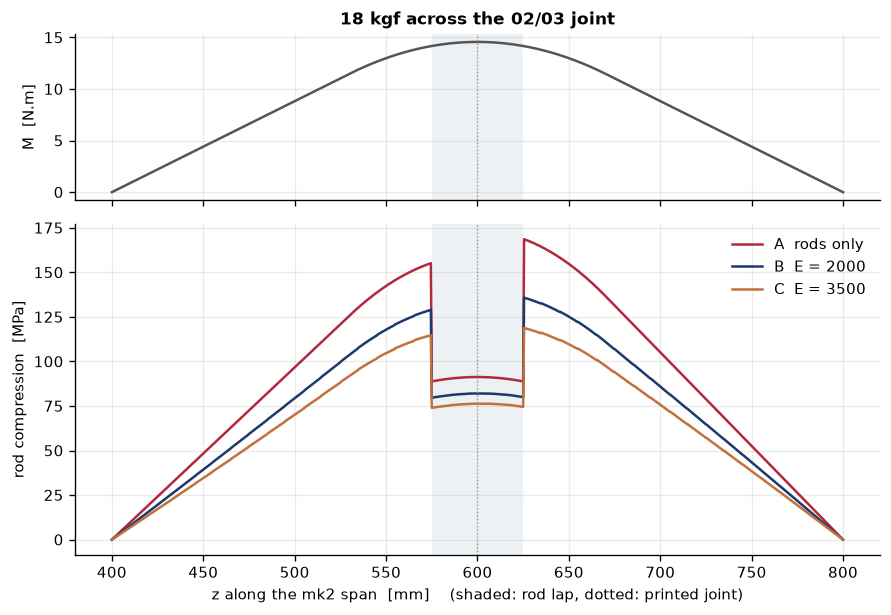

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 5.2), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 2]))
rB = res["B  E = 2000"]
ax1.plot(rB["z"], rB["M"] / 1e3, color="#555")
ax1.set_ylabel("M  [N.m]")
ax1.set_title(f"{t.load_kg:.0f} kgf across the 02/03 joint")
for name, color in (("A  rods only", "#b3283c"), ("B  E = 2000", "#1b3a6b"), ("C  E = 3500", "#c2703d")):
    ax2.plot(res[name]["z"], res[name]["rod_c"], color=color, label=name)
for ax in (ax1, ax2):
    ax.axvspan(z0, z1, color="#1b3a6b", alpha=0.07, lw=0)
    ax.axvline(t.patch_centre, color="#999", lw=0.8, ls=":")
ax2.set_ylabel("rod compression  [MPa]")
ax2.set_xlabel("z along the mk2 span  [mm]    (shaded: rod lap, dotted: printed joint)")
ax2.legend(frameon=False)
fig.tight_layout()
plt.show()

## How much it could have carried

Allowables taken:

* **rod compression**: 494 MPa as a beam on an elastic foundation in 5 % infill (Vesic), 600 MPa material.
  Tension 1500 MPa.
* **skin crown**: face wrinkling into the infill, $0.5\,(E\,E^*G^*)^{1/3}$.
* **lower skin**: 20 MPa tension across layer lines. Untested.
* **bell plug**: $q_{rod}$ over the bell's mouth on the skin, against the 10 % fill's shear strength.
  Foam law $0.2\,\sigma_{ys}\rho^{1.5}$ or truss law $\sigma_{ys}\rho/4$, $\sigma_{ys}$ = 50 MPa.
  Some experiments found the foam law too low for 5 % lattice.
* **shear into the infill**: very light infill carries up to **20 kgf per 10 mm** of rod in pure shear,
  $q_{fill} \approx 19.6$ N/mm. Checked against $q_{rod}$ in the one-pair span and at the lap.
* **lap handover**: the whole force in the rod that ends is passed to its partner over the 50 mm lap.

In [4]:
SIGMA_ROD_C, SIGMA_ROD_T, SIGMA_Z, SIGMA_YS = 600.0, 1500.0, 20.0, 50.0
Q_FILL = 20.0 * G / 10.0      # N/mm  light infill in pure shear: 20 kgf per 10 mm
tau_foam = lambda rho: 0.2 * SIGMA_YS * rho ** 1.5
tau_truss = lambda rho: SIGMA_YS * rho / 4


def rod_foundation(m: Mat) -> float:
    """Vesic Winkler modulus of the infill, P_cr = 2 sqrt(EI k)."""
    EI_rod = m.E_rod * math.pi * t.rod_d ** 4 / 64
    k = 0.65 * t.rod_d * m.E_in / (1 - m.nu ** 2) * (m.E_in * t.rod_d ** 4 / EI_rod) ** (1 / 12)
    return 2 * math.sqrt(EI_rod * k) / t.A_rod


def wrinkling(m: Mat) -> float:
    return 0.5 * (m.E * m.E_in * m.E_in / (2 * (1 + m.nu))) ** (1 / 3)


def bell_mouth(p: dict, z: float, upper: bool) -> float:
    """Width where the bell cup meets the inner skin (builder profile y = h|2u/w|^s)."""
    pts = np.asarray(naca4_polygon_pts(wing.naca, chord_at(z, wing)))
    xa, ya = pts[:, 0], pts[:, 1]
    xb, yb = np.roll(xa, -1), np.roll(ya, -1)
    hit = (xa - p["x"]) * (xb - p["x"]) <= 0
    yc = ya[hit] + (yb[hit] - ya[hit]) * (p["x"] - xa[hit]) / np.where(xb[hit] == xa[hit], 1, xb[hit] - xa[hit])
    y_skin = yc.max() - t.wall_t if upper else yc.min() + t.wall_t
    h = min(abs(y_skin - (p["yu"] if upper else p["yl"])) - wing.bell_offset, wing.bell_height)
    return wing.bell_width * (h / wing.bell_height) ** (1 / wing.bell_shape)


def lap_force(m: Mat) -> float:
    """Largest axial force in a rod as its span ends, either side of the lap."""
    a, b = sorted(t.pairs(), key=lambda p: p["z0"])
    F = 0.0
    for zz, p in ((z0 - 0.5, a), (z1 + 0.5, b)):
        s = section(zz, m)
        _, M = t.loads(np.array([zz]))
        F = max(F, *(abs(m.E_rod * (y - s["y_na"]) * M[0] / s["EI"] * t.A_rod) for y in (p["yu"], p["yl"])))
    return F


def kgf(allow, response):
    return t.load_kg * allow / response


mB, rB, rA, rD = CASES["B  E = 2000"], res["B  E = 2000"], res["A  rods only"], res["D  no rods"]
iq = int(np.argmax(np.where(outside_lap, rB["q"], 0.0)))
pq = next(p for p in t.pairs() if p["z0"] <= rB["z"][iq] <= p["z1"])
mouth = min(bell_mouth(pq, float(rB["z"][iq]), up) for up in (True, False))
q1, F = float(rB["q"][iq]), lap_force(mB)
q_lap = F / (z1 - z0)

print(f"bell mouth {mouth:.1f} mm   q one-pair {q1:.2f} N/mm -> {q1/mouth:.2f} MPa   "
      f"(10 %: foam {tau_foam(t.bell_rho):.2f}, truss {tau_truss(t.bell_rho):.2f})")
print(f"lap handover F = {F:.0f} N over {z1-z0:.0f} mm -> q = {q_lap:.1f} N/mm   "
      f"rod foundation {rod_foundation(mB):.0f} MPa   wrinkling {wrinkling(mB):.1f} MPa")
print(f"shear into infill, capacity {Q_FILL:.1f} N/mm: one-pair span at {100*q1/Q_FILL:.0f} %, "
      f"lap handover at {100*q_lap/Q_FILL:.0f} %\n")

ladders = {
    "A  rods only": [
        (kgf(rod_foundation(mB), rA["rod_c"].max()), "rod compression, foundation"),
        (kgf(SIGMA_ROD_C, rA["rod_c"].max()), "rod compression, material"),
        (kgf(SIGMA_ROD_T, rA["rod_t"].max()), "rod tension"),
    ],
    "B  rods + plastic": [
        (kgf(rod_foundation(mB), rB["rod_c"].max()), "rod compression, foundation"),
        (kgf(SIGMA_ROD_C, rB["rod_c"].max()), "rod compression, material"),
        (kgf(wrinkling(mB), rB["skin_c"].max()), "skin crown wrinkling"),
        (kgf(SIGMA_Z, rB["skin_t"].max()), "lower skin tension across layers"),
        (kgf(tau_foam(t.bell_rho) * mouth, q1), "bell plug, one-pair span, 10 % foam law"),
        (kgf(tau_truss(t.bell_rho) * mouth, q1), "bell plug, one-pair span, 10 % truss law"),
        (kgf(Q_FILL, q1), "shear into infill, one-pair span (20 kgf / 10 mm)"),
        (kgf(Q_FILL, q_lap), "shear into infill, lap handover over 50 mm (20 kgf / 10 mm)"),
    ],
    "D  no rods": [
        (kgf(wrinkling(mB), rD["skin_c"].max()), "skin crown wrinkling"),
        (kgf(SIGMA_Z, rD["skin_t"].max()), "lower skin tension across layers"),
    ],
}
for name, ladder in ladders.items():
    print(name)
    for kg, mode in sorted(ladder):
        flag = ("" if kg >= t.load_kg else "   <- would not have held 18 kgf" if name.startswith("D")
                else "   <- below the 18 kgf it held: falsified")
        print(f"   {kg:6.1f} kgf  x{kg/t.load_kg:4.2f}  {mode}{flag}")

bell mouth 9.0 mm   q one-pair 6.20 N/mm -> 0.69 MPa   (10 %: foam 0.32, truss 1.25)
lap handover F = 960 N over 50 mm -> q = 19.2 N/mm   rod foundation 494 MPa   wrinkling 13.2 MPa
shear into infill, capacity 19.6 N/mm: one-pair span at 32 %, lap handover at 98 %

A  rods only
     52.8 kgf  x2.93  rod compression, foundation
     64.0 kgf  x3.56  rod compression, material
    160.1 kgf  x8.89  rod tension
B  rods + plastic
      8.3 kgf  x0.46  bell plug, one-pair span, 10 % foam law   <- below the 18 kgf it held: falsified
     18.4 kgf  x1.02  shear into infill, lap handover over 50 mm (20 kgf / 10 mm)
     32.7 kgf  x1.82  bell plug, one-pair span, 10 % truss law
     57.0 kgf  x3.17  shear into infill, one-pair span (20 kgf / 10 mm)
     59.5 kgf  x3.30  skin crown wrinkling
     65.5 kgf  x3.64  rod compression, foundation
     79.5 kgf  x4.42  rod compression, material
     95.2 kgf  x5.29  lower skin tension across layers
D  no rods
     11.4 kgf  x0.64  skin crown wrinkling  

## Learnings

Values at 18 kgf, case B, with the A–C range where it matters. It held, so each one is a floor on
what that part can take.

| we learnt | value | against |
|---|---|---|
| rod compression reached | **119–169 MPa** (136 on B), at the lap edge z = 625 | 20–34 % of the 494–600 MPa allowable. Experiment-01 still holds the rod floor, 256–282 MPa |
| rod tension reached | **108–169 MPa** | 7–11 % of 1500 MPa. Not much to learn |
| plastic's share of $EI$, one pair | **up to 32 %, 21 % on B** | 6–9 % on the ellipse and at mk2's root. The rods-only model over-reads rod stress by 24 % here |
| skin crown compression | **4.0–6.1 MPa** | 30–46 % of 13.2 MPa wrinkling |
| shear into the infill, one-pair span | **6.2 N/mm** per rod | **32 %** of the 19.6 N/mm (20 kgf per 10 mm) light infill takes in pure shear |
| shear at the lap handover, pairs 6.5 mm apart | **960 N over 50 mm, 19.2 N/mm** | **98 %** of that same 19.6 N/mm |
| moment across a printed joint, one pair crossing | **≥ 14.6 N.m** | |

**The rods were never the limit.** On rods alone the article carries ~53 kgf before a rod
buckles into the infill. With the plastic the structure reaches ~60 kgf, set by crown
wrinkling and then rod compression. At 18 kgf the rods were at a third of that.

**Bell density matters.** Experiment-01's bell was solid, and the rods broke before it did.
Here it was a 10 % cup ~5 mm tall. A slicer modifier has no perimeter of its own, so a sparse
bell is held only by line ends against the skin and the lattice, and it came out whole. This is perhaps the most important learning of this test: there is still room for improvement on designing the material surrounding the rods.

**Without the rods, the plastic would have failed.** The same shell with empty bores wrinkles at
the crown at ~11 kgf, well under the 18 kgf this article held. On top of that, the full moment
would cross the 15 mm glued slip joint in peel, with nothing continuous through it. The article
held because both rod pairs cross the joint and leave the plastic only its ~20 % share.
